# 06 — Multi-Horizon 24h Sequence Forecasting

**Mục tiêu:** kiểm chứng lại vai trò của các mô hình phức tạp hơn (**TSMixer-lite, PatchTST-lite, iTransformer-mini**) trong một bài toán phù hợp hơn: dự báo **toàn bộ 24 giờ tiếp theo** thay vì chỉ dự báo một điểm đơn lẻ.

Notebook này sử dụng lại các nhóm mô hình đã xuất hiện trong notebook 03.

**Lưu ý quan trọng:** phiên bản này dùng `SAMPLE_STRIDE_HOURS = 6` để tạo các forecast windows bắt đầu ở nhiều thời điểm trong ngày. Nếu chỉ lấy một mẫu/ngày bắt đầu lúc 00:00, horizon 1 và horizon 24 thường rơi vào ban đêm nên RMSE có thể bằng 0, không phản ánh đúng năng lực dự báo. Dùng stride 6 giúp `h1` và `h24` có ý nghĩa hơn khi so sánh với `target_1h` và `target_24h`.

Notebook này sử dụng lại các nhóm mô hình đã xuất hiện trong notebook 03:

- **Linear Regression / Ridge**
- **Random Forest / SVR / MLP**
- **HistGradientBoosting / XGBoost / CatBoost**
- **LSTM / GRU / TSMixer-lite / PatchTST-lite / iTransformer-mini**

Thiết kế chính:

```text
Input : 168 giờ quá khứ
Output: 24 giá trị Solar_Energy_kJ_m2 tiếp theo
```

Từ output 24 giờ, ta đánh giá được:

```text
horizon 1  ≈ target_1h
horizon 24 ≈ target_24h
sum 24h    ≈ daily_total / next-24h total
```


## 0. Thiết lập chung

Notebook đọc 4 file NASA POWER đã tải trong `data_05/`. Output lưu gọn vào `outputs_06/`, `figures_06/`, `models_06/`.

In [1]:
import os, time, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
# =========================
# Configuration
# =========================

DATA_DIR = Path("data_05")
OUT_DIR = Path("outputs_06")
FIG_DIR = Path("figures_06")
MODEL_DIR = Path("models_06")

for d in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LATITUDE = 31.93
LONGITUDE = -4.42

# Multi-horizon forecasting setup
LOOKBACK = 168          # 7 days of hourly history
HORIZON = 24            # predict next 24 hours

# Use rolling forecast starts every 6 hours.
# Do NOT set this to 24 unless you intentionally want only midnight starts.
# With midnight-only starts, h1 and h24 often fall at night and can be 0.
SAMPLE_STRIDE_HOURS = 6

# Time-based split
TRAIN_END = "2018-12-31 23:00:00"
VAL_START = "2019-01-01 00:00:00"
VAL_END = "2020-12-31 23:00:00"
TEST_START = "2021-01-01 00:00:00"
TEST_END = "2023-12-31 23:00:00"

# Model switches
RUN_TABULAR_MODELS = True
RUN_DEEP_MODELS = True
RUN_ENSEMBLE = True
RUN_EXPENSIVE_MODELS = True  
RUN_PERMUTATION_IMPORTANCE = True

# Deep learning config
MAX_EPOCHS = 15
PATIENCE = 4
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

DAYLIGHT_THRESHOLD = 1e-6

print("LOOKBACK:", LOOKBACK)
print("HORIZON:", HORIZON)
print("SAMPLE_STRIDE_HOURS:", SAMPLE_STRIDE_HOURS)
print("MAX_EPOCHS:", MAX_EPOCHS)


LOOKBACK: 168
HORIZON: 24
SAMPLE_STRIDE_HOURS: 6
MAX_EPOCHS: 15


## 1. Đọc dữ liệu NASA POWER 20 năm

In [3]:
manual_files = [
    DATA_DIR / 'nasa_power_errachidia_hourly_2004_2008_LST.csv',
    DATA_DIR / 'nasa_power_errachidia_hourly_2009_2013_LST.csv',
    DATA_DIR / 'nasa_power_errachidia_hourly_2014_2018_LST.csv',
    DATA_DIR / 'nasa_power_errachidia_hourly_2019_2023_LST.csv',
]

missing = [str(p) for p in manual_files if not p.exists()]
if missing:
    raise FileNotFoundError('Missing NASA POWER files:\n' + '\n'.join(missing))


def read_power_csv(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('YEAR'):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f'Cannot find YEAR header row in {path}')
    return pd.read_csv(path, skiprows=header_idx)

raw_parts = []
for path in manual_files:
    part = read_power_csv(path)
    raw_parts.append(part)
    print(path.name, part.shape)

raw_df = pd.concat(raw_parts, ignore_index=True)
raw_df = raw_df.drop_duplicates(subset=['YEAR', 'MO', 'DY', 'HR']).copy()
raw_df = raw_df.sort_values(['YEAR', 'MO', 'DY', 'HR']).reset_index(drop=True)
print('Combined raw shape:', raw_df.shape)
display(raw_df.head())
display(raw_df.tail())

nasa_power_errachidia_hourly_2004_2008_LST.csv (43848, 10)
nasa_power_errachidia_hourly_2009_2013_LST.csv (43824, 10)
nasa_power_errachidia_hourly_2014_2018_LST.csv (43824, 10)
nasa_power_errachidia_hourly_2019_2023_LST.csv (43824, 10)
Combined raw shape: (175320, 10)


,YEAR,MO,DY,HR,PS,WS10M,WD10M,RH2M,ALLSKY_SFC_SW_DWN,T2M
0,2004,1,1,0,87.48,3.75,331.3,90.18,0.0,3.69
1,2004,1,1,1,87.49,4.01,336.3,93.09,0.0,3.38
2,2004,1,1,2,87.48,4.20,340.8,94.70,0.0,3.19
3,2004,1,1,3,87.45,4.40,342.8,95.65,0.0,2.99
4,2004,1,1,4,87.42,4.31,342.0,96.39,0.0,2.74


,YEAR,MO,DY,HR,PS,WS10M,WD10M,RH2M,ALLSKY_SFC_SW_DWN,T2M
175315,2023,12,31,19,87.44,3.05,189.8,30.12,0.0,7.60
175316,2023,12,31,20,87.48,2.89,205.6,32.86,0.0,6.53
175317,2023,12,31,21,87.49,2.75,218.7,34.88,0.0,5.86
175318,2023,12,31,22,87.49,2.53,227.7,35.23,0.0,5.90
175319,2023,12,31,23,87.46,2.32,232.5,35.37,0.0,5.84


## 2. Tiền xử lý hourly data và tạo feature vật lý cơ bản

In [4]:
rename_map = {
    'PS': 'Pressure',
    'WS10M': 'Wind_Speed',
    'WD10M': 'Wind_Direction',
    'RH2M': 'Humidity',
    'ALLSKY_SFC_SW_DWN': 'Solar_Radiation_Wh_m2',
    'T2M': 'Temperature',
}

hourly = raw_df.rename(columns=rename_map).copy()
hourly['datetime'] = pd.to_datetime(
    dict(year=hourly['YEAR'], month=hourly['MO'], day=hourly['DY'], hour=hourly['HR']),
    errors='coerce'
)
hourly = hourly.dropna(subset=['datetime']).set_index('datetime').sort_index()

core_cols = ['Pressure', 'Wind_Speed', 'Wind_Direction', 'Humidity', 'Solar_Radiation_Wh_m2', 'Temperature']
for c in core_cols:
    hourly[c] = pd.to_numeric(hourly[c], errors='coerce')

hourly = hourly.replace([np.inf, -np.inf], np.nan).dropna(subset=core_cols).copy()
hourly['Solar_Energy_kJ_m2'] = hourly['Solar_Radiation_Wh_m2'] * 3.6

hourly['hour'] = hourly.index.hour
hourly['dayofyear'] = hourly.index.dayofyear
hourly['month'] = hourly.index.month
hourly['hour_sin'] = np.sin(2*np.pi*hourly['hour']/24)
hourly['hour_cos'] = np.cos(2*np.pi*hourly['hour']/24)
hourly['doy_sin'] = np.sin(2*np.pi*hourly['dayofyear']/365.25)
hourly['doy_cos'] = np.cos(2*np.pi*hourly['dayofyear']/365.25)
hourly['month_sin'] = np.sin(2*np.pi*hourly['month']/12)
hourly['month_cos'] = np.cos(2*np.pi*hourly['month']/12)
hourly['wind_dir_sin'] = np.sin(np.deg2rad(hourly['Wind_Direction']))
hourly['wind_dir_cos'] = np.cos(np.deg2rad(hourly['Wind_Direction']))

lat_rad = np.deg2rad(LATITUDE)
doy = hourly.index.dayofyear.values
hr = hourly.index.hour.values + 0.5
decl = np.deg2rad(23.44) * np.sin(2*np.pi*(doy-81)/365.25)
hour_angle = np.deg2rad(15*(hr-12))
sin_elev = np.sin(lat_rad)*np.sin(decl) + np.cos(lat_rad)*np.cos(decl)*np.cos(hour_angle)
sin_elev = np.clip(sin_elev, -1, 1)
hourly['solar_elevation_proxy_deg'] = np.rad2deg(np.arcsin(sin_elev))
hourly['sun_up_proxy'] = (hourly['solar_elevation_proxy_deg'] > 0).astype(int)
hourly['clear_sky_ghi_proxy_Wh_m2'] = np.maximum(0, sin_elev) * 1000.0
hourly['clear_sky_index_current'] = hourly['Solar_Radiation_Wh_m2'] / hourly['clear_sky_ghi_proxy_Wh_m2'].replace(0, np.nan)
hourly['clear_sky_index_current'] = hourly['clear_sky_index_current'].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 2)
hourly['sim_cell_temperature_C'] = hourly['Temperature'] + 0.03 * hourly['Solar_Radiation_Wh_m2']
hourly['sim_pv_dc_kWh_per_kWp'] = (hourly['Solar_Radiation_Wh_m2']/1000.0) * (1 - 0.004*(hourly['sim_cell_temperature_C']-25))
hourly['sim_pv_dc_kWh_per_kWp'] = hourly['sim_pv_dc_kWh_per_kWp'].clip(lower=0)
hourly['sim_pv_ac_kWh_per_kWp'] = hourly['sim_pv_dc_kWh_per_kWp'] * 0.96
hourly = hourly.loc[:, ~hourly.columns.duplicated()].copy()

print('Hourly shape:', hourly.shape)
print('Date range:', hourly.index.min(), '→', hourly.index.max())
display(hourly[core_cols + ['Solar_Energy_kJ_m2']].describe().T)
display(hourly.head())

Hourly shape: (175320, 29)
Date range: 2004-01-01 00:00:00 → 2023-12-31 23:00:00


,count,mean,std,min,25%,50%,75%,max
Pressure,175320.0,87.234426,0.459055,84.60,86.97,87.270,87.53,88.97
Wind_Speed,175320.0,3.675372,2.193684,0.01,2.09,3.190,4.84,18.39
Wind_Direction,175320.0,191.409155,113.567571,0.00,102.50,196.500,299.60,359.90
Humidity,175320.0,42.343535,23.152266,2.51,22.72,39.380,58.80,100.00
Solar_Radiation_Wh_m2,175320.0,243.867370,323.542565,0.00,0.00,10.480,493.75,1103.60
Temperature,175320.0,17.361122,9.923770,-6.00,9.34,16.940,24.58,41.55
Solar_Energy_kJ_m2,175320.0,877.922532,1164.753233,0.00,0.00,37.728,1777.50,3972.96


,YEAR,MO,DY,HR,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation_Wh_m2,Temperature,...,month_cos,wind_dir_sin,wind_dir_cos,solar_elevation_proxy_deg,sun_up_proxy,clear_sky_ghi_proxy_Wh_m2,clear_sky_index_current,sim_cell_temperature_C,sim_pv_dc_kWh_per_kWp,sim_pv_ac_kWh_per_kWp
datetime,,,,,,,,,,,,,,,,,,,,,
2004-01-01 00:00:00,2004,1,1,0,87.48,3.75,331.3,90.18,0.0,3.69,...,0.866025,-0.480223,0.877146,-78.869038,0,0.0,0.0,3.69,0.0,0.0
2004-01-01 01:00:00,2004,1,1,1,87.49,4.01,336.3,93.09,0.0,3.38,...,0.866025,-0.401948,0.915663,-68.187320,0,0.0,0.0,3.38,0.0,0.0
2004-01-01 02:00:00,2004,1,1,2,87.48,4.20,340.8,94.70,0.0,3.19,...,0.866025,-0.328867,0.944376,-55.733852,0,0.0,0.0,3.19,0.0,0.0
2004-01-01 03:00:00,2004,1,1,3,87.45,4.40,342.8,95.65,0.0,2.99,...,0.866025,-0.295708,0.955278,-43.017379,0,0.0,0.0,2.99,0.0,0.0
2004-01-01 04:00:00,2004,1,1,4,87.42,4.31,342.0,96.39,0.0,2.74,...,0.866025,-0.309017,0.951057,-30.371095,0,0.0,0.0,2.74,0.0,0.0


## 3. Tạo dữ liệu multi-horizon sequence

In [5]:
sequence_features = [
    'Solar_Energy_kJ_m2', 'Solar_Radiation_Wh_m2', 'Temperature', 'Humidity', 'Pressure', 'Wind_Speed',
    'wind_dir_sin', 'wind_dir_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos',
    'solar_elevation_proxy_deg', 'sun_up_proxy', 'clear_sky_ghi_proxy_Wh_m2', 'clear_sky_index_current',
    'sim_cell_temperature_C', 'sim_pv_ac_kWh_per_kWp'
]
sequence_features = [c for c in sequence_features if c in hourly.columns]
sequence_features = list(dict.fromkeys(sequence_features))
TARGET_COL = 'Solar_Energy_kJ_m2'
print('Number of sequence features:', len(sequence_features))
print(sequence_features)

Number of sequence features: 20
['Solar_Energy_kJ_m2', 'Solar_Radiation_Wh_m2', 'Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'wind_dir_sin', 'wind_dir_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'solar_elevation_proxy_deg', 'sun_up_proxy', 'clear_sky_ghi_proxy_Wh_m2', 'clear_sky_index_current', 'sim_cell_temperature_C', 'sim_pv_ac_kWh_per_kWp']


In [6]:
def build_multihorizon_arrays(df, feature_cols, target_col, lookback, horizon, stride):
    values = df[feature_cols].astype(np.float32).values
    target = df[target_col].astype(np.float32).values
    times = pd.DatetimeIndex(df.index)

    X_list, Y_list, anchor_times = [], [], []

    max_anchor = len(df) - horizon
    for t in range(lookback, max_anchor + 1, stride):
        x_window = values[t - lookback:t]
        y_future = target[t:t + horizon]

        if np.isfinite(x_window).all() and np.isfinite(y_future).all():
            X_list.append(x_window)
            Y_list.append(y_future)
            anchor_times.append(times[t])

    if not X_list:
        raise ValueError("No valid multi-horizon samples were created. Check data, lookback, horizon, and stride.")

    return (
        np.stack(X_list).astype(np.float32),
        np.stack(Y_list).astype(np.float32),
        pd.DatetimeIndex(anchor_times),
    )

X_all_raw, Y_all_raw, anchor_times = build_multihorizon_arrays(
    hourly,
    sequence_features,
    TARGET_COL,
    LOOKBACK,
    HORIZON,
    SAMPLE_STRIDE_HOURS,
)

print("X_all_raw:", X_all_raw.shape)
print("Y_all_raw:", Y_all_raw.shape)
print("Anchor range:", anchor_times.min(), "→", anchor_times.max())


X_all_raw: (29189, 168, 20)
Y_all_raw: (29189, 24)
Anchor range: 2004-01-08 00:00:00 → 2023-12-31 00:00:00


In [7]:
train_mask = anchor_times <= pd.Timestamp(TRAIN_END)
val_mask = (anchor_times >= pd.Timestamp(VAL_START)) & (anchor_times <= pd.Timestamp(VAL_END))
test_mask = (anchor_times >= pd.Timestamp(TEST_START)) & (anchor_times <= pd.Timestamp(TEST_END))

X_train_raw, Y_train = X_all_raw[train_mask], Y_all_raw[train_mask]
X_val_raw, Y_val = X_all_raw[val_mask], Y_all_raw[val_mask]
X_test_raw, Y_test = X_all_raw[test_mask], Y_all_raw[test_mask]
train_times, val_times, test_times = anchor_times[train_mask], anchor_times[val_mask], anchor_times[test_mask]

print('Train:', X_train_raw.shape, Y_train.shape, train_times.min(), '→', train_times.max())
print('Val  :', X_val_raw.shape, Y_val.shape, val_times.min(), '→', val_times.max())
print('Test :', X_test_raw.shape, Y_test.shape, test_times.min(), '→', test_times.max())
print("\nAnchor hour distribution:")
anchor_hour_counts = pd.Series(anchor_times.hour).value_counts().sort_index()
display(anchor_hour_counts.to_frame("n_samples"))

if len(anchor_hour_counts) == 1:
    only_hour = int(anchor_hour_counts.index[0])
    print(
        f"WARNING: All forecast windows start at hour {only_hour}. "
        "Horizon-specific metrics such as h1 and h24 may be dominated by a fixed hour of day."
    )


Train: (21888, 168, 20) (21888, 24) 2004-01-08 00:00:00 → 2018-12-31 18:00:00
Val  : (2924, 168, 20) (2924, 24) 2019-01-01 00:00:00 → 2020-12-31 18:00:00
Test : (4377, 168, 20) (4377, 24) 2021-01-01 00:00:00 → 2023-12-31 00:00:00

Anchor hour distribution:


,n_samples
0,7298
6,7297
12,7297
18,7297


## 4. Metrics

In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))))

def safe_r2(y_true, y_pred):
    try:
        return float(r2_score(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1)))
    except Exception:
        return np.nan

def as_2d_horizon(y):
    y = np.asarray(y, dtype=np.float64)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return y

def align_2d_arrays(*arrays):
    clean = [as_2d_horizon(a) for a in arrays if a is not None]
    n = min(len(a) for a in clean)
    return [a[-n:] for a in clean]

def evaluate_24h(y_true, y_pred, persistence_pred=None, daylight_threshold=DAYLIGHT_THRESHOLD):
    """Evaluate a 24-step forecast.

    y_true and y_pred must have shape (n_samples, HORIZON).
    h1_RMSE and h24_RMSE are computed from horizon 1 and horizon 24.
    If forecast windows all start at midnight, h1/h24 can be near 0 because
    those horizons may correspond to night hours. This is not a metric bug.
    """
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[-n:]
    y_pred = y_pred[-n:]

    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch after alignment: y_true={y_true.shape}, y_pred={y_pred.shape}")

    yt_flat = y_true.reshape(-1)
    yp_flat = y_pred.reshape(-1)

    overall_rmse = np.sqrt(mean_squared_error(yt_flat, yp_flat))
    out = {
        "RMSE": float(overall_rmse),
        "MAE": float(mean_absolute_error(yt_flat, yp_flat)),
        "R2": safe_r2(yt_flat, yp_flat),
        "MaxError": float(max_error(yt_flat, yp_flat)),
        "NRMSE": float(overall_rmse / (yt_flat.max() - yt_flat.min())) if (yt_flat.max() - yt_flat.min()) != 0 else np.nan,
    }

    # Daylight-only metrics over all horizons
    daylight_mask = yt_flat > daylight_threshold
    if daylight_mask.sum() > 5:
        yt_day = yt_flat[daylight_mask]
        yp_day = yp_flat[daylight_mask]
        daylight_rmse = np.sqrt(mean_squared_error(yt_day, yp_day))
        out.update({
            "daylight_RMSE": float(daylight_rmse),
            "daylight_MAE": float(mean_absolute_error(yt_day, yp_day)),
            "daylight_R2": safe_r2(yt_day, yp_day),
            "daylight_NRMSE": float(daylight_rmse / (yt_day.max() - yt_day.min())) if (yt_day.max() - yt_day.min()) != 0 else np.nan,
        })
    else:
        out.update({
            "daylight_RMSE": np.nan,
            "daylight_MAE": np.nan,
            "daylight_R2": np.nan,
            "daylight_NRMSE": np.nan,
        })

    # Horizon-specific metrics
    for h in range(y_true.shape[1]):
        yt_h = y_true[:, h]
        yp_h = y_pred[:, h]
        out[f"horizon_{h+1}_RMSE"] = float(np.sqrt(mean_squared_error(yt_h, yp_h)))
        out[f"horizon_{h+1}_MAE"] = float(mean_absolute_error(yt_h, yp_h))
        mask_h = yt_h > daylight_threshold
        out[f"horizon_{h+1}_daylight_RMSE"] = (
            float(np.sqrt(mean_squared_error(yt_h[mask_h], yp_h[mask_h])))
            if mask_h.sum() > 5 else np.nan
        )

    out["h1_RMSE"] = out.get("horizon_1_RMSE", np.nan)
    out["h24_RMSE"] = out.get("horizon_24_RMSE", np.nan)
    out["h1_daylight_RMSE"] = out.get("horizon_1_daylight_RMSE", np.nan)
    out["h24_daylight_RMSE"] = out.get("horizon_24_daylight_RMSE", np.nan)

    # Midday-like horizon: useful when midnight-start windows make h1/h24 uninformative
    if y_true.shape[1] >= 12:
        out["h12_RMSE"] = out.get("horizon_12_RMSE", np.nan)
        out["h12_daylight_RMSE"] = out.get("horizon_12_daylight_RMSE", np.nan)
    else:
        out["h12_RMSE"] = np.nan
        out["h12_daylight_RMSE"] = np.nan

    # Total energy over the next 24 forecasted hours
    true_daily_total = y_true.sum(axis=1)
    pred_daily_total = y_pred.sum(axis=1)
    daily_total_rmse = np.sqrt(mean_squared_error(true_daily_total, pred_daily_total))
    out.update({
        "daily_total_RMSE": float(daily_total_rmse),
        "daily_total_MAE": float(mean_absolute_error(true_daily_total, pred_daily_total)),
        "daily_total_R2": safe_r2(true_daily_total, pred_daily_total),
        "daily_total_NRMSE": float(daily_total_rmse / (true_daily_total.max() - true_daily_total.min())) if (true_daily_total.max() - true_daily_total.min()) != 0 else np.nan,
    })

    # Skill vs persistence
    if persistence_pred is not None:
        p = np.asarray(persistence_pred, dtype=np.float32)
        if p.ndim == 1:
            p = p.reshape(-1, 1)

        m = min(len(y_true), len(p))
        yt_skill = y_true[-m:]
        yp_skill = y_pred[-m:]
        p_skill = p[-m:]

        yt_flat_skill = yt_skill.reshape(-1)
        yp_flat_skill = yp_skill.reshape(-1)
        p_flat_skill = p_skill.reshape(-1)

        mask = yt_flat_skill > daylight_threshold
        if mask.sum() > 5:
            model_rmse = np.sqrt(mean_squared_error(yt_flat_skill[mask], yp_flat_skill[mask]))
            persistence_rmse = np.sqrt(mean_squared_error(yt_flat_skill[mask], p_flat_skill[mask]))
            out["skill_vs_persistence_daylight"] = float(1 - model_rmse / persistence_rmse) if persistence_rmse > 0 else np.nan
        else:
            out["skill_vs_persistence_daylight"] = np.nan
    else:
        out["skill_vs_persistence_daylight"] = np.nan

    return out

def horizon_metrics(y_true, y_pred, model_name, split_name):
    y_true = as_2d_horizon(y_true)
    y_pred = np.clip(as_2d_horizon(y_pred), 0, None)
    y_true, y_pred = align_2d_arrays(y_true, y_pred)

    rows = []
    for h in range(y_true.shape[1]):
        yt = y_true[:, h]
        yp = y_pred[:, h]
        mask = yt > DAYLIGHT_THRESHOLD

        rows.append({
            "split": split_name,
            "model": model_name,
            "horizon": h + 1,
            "RMSE": rmse(yt, yp),
            "MAE": float(mean_absolute_error(yt, yp)),
            "R2": safe_r2(yt, yp),
            "daylight_RMSE": float(np.sqrt(mean_squared_error(yt[mask], yp[mask]))) if mask.sum() > 5 else np.nan,
            "n_daylight": int(mask.sum()),
        })

    return rows

def print_metric_short(prefix, metrics):
    print(
        f"{prefix:<35} | "
        f"RMSE={metrics.get('RMSE', np.nan):9.3f} | "
        f"daylight_RMSE={metrics.get('daylight_RMSE', np.nan):9.3f} | "
        f"h1={metrics.get('h1_RMSE', np.nan):9.3f} | "
        f"h12={metrics.get('h12_RMSE', np.nan):9.3f} | "
        f"h24={metrics.get('h24_RMSE', np.nan):9.3f} | "
        f"daily_total_RMSE={metrics.get('daily_total_RMSE', np.nan):9.3f}"
    )


## 5. Naive baselines

In [9]:
target_idx = sequence_features.index("Solar_Energy_kJ_m2")

def baseline_predictions(X_raw):
    last_value = X_raw[:, -1, target_idx]

    # Naive persistence: repeat the most recent value for all 24 future hours
    persistence_current = np.repeat(last_value[:, None], HORIZON, axis=1)

    # Seasonal persistence: use the same 24-hour curve from yesterday
    seasonal_yesterday = X_raw[:, -24:, target_idx]

    # Weekly seasonal persistence: use the same 24-hour curve from one week ago
    seasonal_weekly = X_raw[:, -168:-144, target_idx]

    return {
        "Persistence_current": persistence_current.astype(np.float32),
        "SeasonalPersistence_yesterday": seasonal_yesterday.astype(np.float32),
        "SeasonalPersistence_weekly": seasonal_weekly.astype(np.float32),
    }

baseline_val = baseline_predictions(X_val_raw)
baseline_test = baseline_predictions(X_test_raw)

results_rows, horizon_rows, predictions = [], [], {}

# Use yesterday seasonal persistence as skill baseline because it is a strong domain baseline for solar data
skill_baseline_val = baseline_val["SeasonalPersistence_yesterday"]
skill_baseline_test = baseline_test["SeasonalPersistence_yesterday"]

for model_name in baseline_val:
    val_pred = baseline_val[model_name]
    test_pred = baseline_test[model_name]

    val_metrics = evaluate_24h(Y_val, val_pred, persistence_pred=skill_baseline_val)
    test_metrics = evaluate_24h(Y_test, test_pred, persistence_pred=skill_baseline_test)

    results_rows.append({
        "model": model_name,
        "model_group": "naive_baseline",
        "train_seconds": 0.0,
        "status": "ok",
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    })

    predictions[model_name] = {
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

    horizon_rows += horizon_metrics(Y_test, test_pred, model_name, "test")
    print_metric_short(model_name + " Test", test_metrics)


Persistence_current Test            | RMSE= 1669.004 | daylight_RMSE= 1842.369 | h1=  260.564 | h12= 2111.038 | h24=  227.751 | daily_total_RMSE=29463.690
SeasonalPersistence_yesterday Test  | RMSE=  244.328 | daylight_RMSE=  339.524 | h1=  228.916 | h12=  227.756 | h24=  227.751 | daily_total_RMSE= 3062.491
SeasonalPersistence_weekly Test     | RMSE=  293.976 | daylight_RMSE=  408.514 | h1=  273.216 | h12=  280.354 | h24=  280.151 | daily_total_RMSE= 3983.165


## 6. Tabular features cho các mô hình ML/Boosting

In [10]:
def make_tabular_features(X_raw, anchor_times, feature_cols):
    rows = []
    idx_map = {c: i for i, c in enumerate(feature_cols)}

    def get_series(x, name):
        return x[:, idx_map[name]] if name in idx_map else None

    vars_stats = [
        "Solar_Energy_kJ_m2",
        "Solar_Radiation_Wh_m2",
        "Temperature",
        "Humidity",
        "Pressure",
        "Wind_Speed",
        "clear_sky_index_current",
        "sim_pv_ac_kWh_per_kWp",
    ]

    lag_hours = [1, 2, 3, 6, 12, 24, 48, 168]
    windows = [3, 6, 24, 72, 168]

    for sample_idx in range(X_raw.shape[0]):
        x = X_raw[sample_idx]
        row = {}

        # Historical lag and rolling features from the lookback window
        for var in vars_stats:
            s = get_series(x, var)
            if s is None:
                continue

            for lag in lag_hours:
                if lag <= len(s):
                    row[f"{var}_lag_{lag}h"] = float(s[-lag])

            for w in windows:
                if w <= len(s):
                    part = s[-w:]
                    row[f"{var}_mean_{w}h"] = float(np.mean(part))
                    row[f"{var}_std_{w}h"] = float(np.std(part))
                    row[f"{var}_min_{w}h"] = float(np.min(part))
                    row[f"{var}_max_{w}h"] = float(np.max(part))

        # Last known calendar/physical state
        for var in [
            "hour_sin",
            "hour_cos",
            "doy_sin",
            "doy_cos",
            "month_sin",
            "month_cos",
            "solar_elevation_proxy_deg",
            "sun_up_proxy",
        ]:
            s = get_series(x, var)
            if s is not None:
                row[f"last_{var}"] = float(s[-1])

        # Known future calendar/solar geometry features for each forecast horizon
        anchor = pd.Timestamp(anchor_times[sample_idx])
        future_times = pd.date_range(anchor, periods=HORIZON, freq="h")

        future_hour = future_times.hour.values + 0.5
        future_doy = future_times.dayofyear.values
        future_month = future_times.month.values

        lat_rad = np.deg2rad(LATITUDE)
        decl = np.deg2rad(23.44) * np.sin(2 * np.pi * (future_doy - 81) / 365.25)
        hour_angle = np.deg2rad(15 * (future_hour - 12))
        sin_elev = np.sin(lat_rad) * np.sin(decl) + np.cos(lat_rad) * np.cos(decl) * np.cos(hour_angle)
        sin_elev = np.clip(sin_elev, -1, 1)
        elev = np.rad2deg(np.arcsin(sin_elev))

        for h in range(HORIZON):
            row[f"future_h{h+1}_hour_sin"] = float(np.sin(2 * np.pi * future_times[h].hour / 24))
            row[f"future_h{h+1}_hour_cos"] = float(np.cos(2 * np.pi * future_times[h].hour / 24))
            row[f"future_h{h+1}_doy_sin"] = float(np.sin(2 * np.pi * future_doy[h] / 365.25))
            row[f"future_h{h+1}_doy_cos"] = float(np.cos(2 * np.pi * future_doy[h] / 365.25))
            row[f"future_h{h+1}_month_sin"] = float(np.sin(2 * np.pi * future_month[h] / 12))
            row[f"future_h{h+1}_month_cos"] = float(np.cos(2 * np.pi * future_month[h] / 12))
            row[f"future_h{h+1}_solar_elevation_proxy_deg"] = float(elev[h])
            row[f"future_h{h+1}_clear_sky_proxy"] = float(max(0, sin_elev[h]) * 1000.0)

        rows.append(row)

    X_tab = pd.DataFrame(rows, index=pd.DatetimeIndex(anchor_times))
    X_tab = X_tab.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

    # Force all features into float32 for XGBoost/CatBoost/sklearn compatibility
    X_tab = X_tab.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)

    return X_tab.astype(np.float32)

X_train_tab = make_tabular_features(X_train_raw, train_times, sequence_features)
X_val_tab = make_tabular_features(X_val_raw, val_times, sequence_features)
X_test_tab = make_tabular_features(X_test_raw, test_times, sequence_features)

print("X_train_tab:", X_train_tab.shape, "| duplicated cols:", X_train_tab.columns.duplicated().sum())
print("X_val_tab  :", X_val_tab.shape, "| duplicated cols:", X_val_tab.columns.duplicated().sum())
print("X_test_tab :", X_test_tab.shape, "| duplicated cols:", X_test_tab.columns.duplicated().sum())

display(X_train_tab.head())


X_train_tab: (21888, 424) | duplicated cols: 0
X_val_tab  : (2924, 424) | duplicated cols: 0
X_test_tab : (4377, 424) | duplicated cols: 0


,Solar_Energy_kJ_m2_lag_1h,Solar_Energy_kJ_m2_lag_2h,Solar_Energy_kJ_m2_lag_3h,Solar_Energy_kJ_m2_lag_6h,Solar_Energy_kJ_m2_lag_12h,Solar_Energy_kJ_m2_lag_24h,Solar_Energy_kJ_m2_lag_48h,Solar_Energy_kJ_m2_lag_168h,Solar_Energy_kJ_m2_mean_3h,Solar_Energy_kJ_m2_std_3h,...,future_h23_solar_elevation_proxy_deg,future_h23_clear_sky_proxy,future_h24_hour_sin,future_h24_hour_cos,future_h24_doy_sin,future_h24_doy_cos,future_h24_month_sin,future_h24_month_cos,future_h24_solar_elevation_proxy_deg,future_h24_clear_sky_proxy
2004-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,1875.312012,0.000000,0.000000,0.000000,0.000000,0.000000,...,-67.833611,0.000000,-0.258819,0.965926,0.137185,0.990545,0.5,0.866025,-78.279701,0.000000
2004-01-08 06:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-30.017990,0.000000,0.965926,0.258819,0.154204,0.988039,0.5,0.866025,-17.582130,0.000000
2004-01-08 12:00:00,1935.432007,1726.128052,1225.800049,0.000000,0.000000,1875.312012,2264.687988,2226.780029,1629.120117,297.716095,...,31.783155,526.705933,0.258819,-0.965926,0.154204,0.988039,0.5,0.866025,35.437408,579.813293
2004-01-08 18:00:00,32.040001,531.719971,1207.728027,2261.340088,0.000000,0.000000,0.000000,0.000000,590.496033,481.768677,...,5.815059,101.317780,-0.965926,-0.258819,0.154204,0.988039,0.5,0.866025,-5.559624,0.000000
2004-01-09 00:00:00,0.000000,0.000000,0.000000,0.000000,2261.340088,0.000000,0.000000,0.000000,0.000000,0.000000,...,-67.768097,0.000000,-0.258819,0.965926,0.154204,0.988039,0.5,0.866025,-78.172012,0.000000


## 7. Train tabular models: Linear/Ridge, Random Forest, SVR, MLP, HistGradientBoosting, XGBoost, CatBoost

In [11]:
def clean_model_name(name):
    return (
        name.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("+", "plus")
    )

def ensure_2d_prediction(pred, n_samples=None, horizon=HORIZON):
    pred = np.asarray(pred)
    if pred.ndim == 1:
        pred = pred.reshape(-1, 1)

    # Some wrappers can return shape (horizon, n_samples); fix if needed
    if n_samples is not None and pred.shape[0] != n_samples and pred.shape[-1] == n_samples:
        pred = pred.T

    if pred.shape[1] != horizon:
        raise ValueError(f"Prediction shape mismatch. Expected horizon={horizon}, got shape={pred.shape}")

    return np.clip(pred.astype(np.float32), 0, None)

def make_catboost_multioutput_fallback():
    return MultiOutputRegressor(
        CatBoostRegressor(
            iterations=350,
            learning_rate=0.04,
            depth=6,
            loss_function="RMSE",
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
        ),
        n_jobs=1,
    )

def get_tabular_models():
    models = {
        "Linear Regression": LinearRegression(),

        "Ridge": make_pipeline(
            StandardScaler(),
            Ridge(alpha=10.0, random_state=SEED),
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=220,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1,
        ),

        # HistGradientBoostingRegressor does not support multi-output natively.
        "HistGradientBoosting": MultiOutputRegressor(
            HistGradientBoostingRegressor(
                max_iter=350,
                learning_rate=0.05,
                max_leaf_nodes=63,
                l2_regularization=0.1,
                random_state=SEED,
            ),
            n_jobs=1,
        ),

        # MultiOutputRegressor is used to be robust across XGBoost versions.
        "XGBoost": MultiOutputRegressor(
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.04,
                max_depth=5,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=2,
                tree_method="hist",
            ),
            n_jobs=1,
        ),

        # CatBoost supports multi-target regression with MultiRMSE in many versions.
        # If it fails, the training loop automatically retries with MultiOutputRegressor.
        "CatBoost": CatBoostRegressor(
            iterations=450,
            learning_rate=0.04,
            depth=6,
            loss_function="MultiRMSE",
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
        ),
    }

    if RUN_EXPENSIVE_MODELS:
        models["SVR"] = MultiOutputRegressor(
            make_pipeline(
                StandardScaler(),
                SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.1),
            ),
            n_jobs=1,
        )

        models["MLP"] = make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                batch_size=256,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
                random_state=SEED,
            ),
        )

    return models

if RUN_TABULAR_MODELS:
    tabular_models = get_tabular_models()

    for model_name, model in tabular_models.items():
        print("\n" + "=" * 90)
        print("Training", model_name)

        start = time.time()

        try:
            try:
                model.fit(X_train_tab, Y_train)
            except Exception as first_err:
                if model_name == "CatBoost":
                    print("CatBoost MultiRMSE failed, retrying with MultiOutputRegressor fallback.")
                    print("Original error:", repr(first_err))
                    model = make_catboost_multioutput_fallback()
                    model.fit(X_train_tab, Y_train)
                else:
                    raise first_err

            elapsed = time.time() - start

            val_pred = ensure_2d_prediction(model.predict(X_val_tab), n_samples=len(X_val_tab), horizon=HORIZON)
            test_pred = ensure_2d_prediction(model.predict(X_test_tab), n_samples=len(X_test_tab), horizon=HORIZON)

            val_metrics = evaluate_24h(Y_val, val_pred, persistence_pred=skill_baseline_val)
            test_metrics = evaluate_24h(Y_test, test_pred, persistence_pred=skill_baseline_test)

            results_rows.append({
                "model": model_name,
                "model_group": "tabular_ml",
                "train_seconds": elapsed,
                "status": "ok",
                **{f"val_{k}": v for k, v in val_metrics.items()},
                **{f"test_{k}": v for k, v in test_metrics.items()},
            })

            predictions[model_name] = {
                "val_pred": val_pred,
                "test_pred": test_pred,
                "model": model,
            }

            horizon_rows += horizon_metrics(Y_test, test_pred, model_name, "test")

            joblib.dump(model, MODEL_DIR / f"06_{clean_model_name(model_name)}.joblib")

            print_metric_short(model_name + " Val ", val_metrics)
            print_metric_short(model_name + " Test", test_metrics)

        except Exception as e:
            elapsed = time.time() - start
            print("Failed:", repr(e))
            results_rows.append({
                "model": model_name,
                "model_group": "tabular_ml",
                "train_seconds": elapsed,
                "status": f"failed: {repr(e)}",
            })



Training Linear Regression
Linear Regression Val               | RMSE=  179.034 | daylight_RMSE=  247.563 | h1=   72.969 | h12=  175.700 | h24=  176.708 | daily_total_RMSE= 2217.421
Linear Regression Test              | RMSE=  195.195 | daylight_RMSE=  270.336 | h1=   81.953 | h12=  188.443 | h24=  187.266 | daily_total_RMSE= 2512.318

Training Ridge
Ridge Val                           | RMSE=  172.084 | daylight_RMSE=  237.486 | h1=   68.483 | h12=  171.473 | h24=  174.186 | daily_total_RMSE= 2155.889
Ridge Test                          | RMSE=  188.313 | daylight_RMSE=  260.259 | h1=   78.429 | h12=  183.166 | h24=  186.208 | daily_total_RMSE= 2430.298

Training Random Forest
Random Forest Val                   | RMSE=  171.058 | daylight_RMSE=  237.730 | h1=   71.000 | h12=  173.747 | h24=  178.810 | daily_total_RMSE= 2199.217
Random Forest Test                  | RMSE=  187.412 | daylight_RMSE=  260.429 | h1=   79.595 | h12=  184.952 | h24=  189.879 | daily_total_RMSE= 2467.249

T

## 8. Chuẩn hóa dữ liệu cho deep sequence models

In [12]:
x_scaler = StandardScaler()
x_scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))

X_train = x_scaler.transform(X_train_raw.reshape(-1, X_train_raw.shape[-1])).reshape(X_train_raw.shape).astype(np.float32)
X_val = x_scaler.transform(X_val_raw.reshape(-1, X_val_raw.shape[-1])).reshape(X_val_raw.shape).astype(np.float32)
X_test = x_scaler.transform(X_test_raw.reshape(-1, X_test_raw.shape[-1])).reshape(X_test_raw.shape).astype(np.float32)

y_scaler = StandardScaler()
y_scaler.fit(Y_train.reshape(-1, 1))

Y_train_scaled = y_scaler.transform(Y_train.reshape(-1, 1)).reshape(Y_train.shape).astype(np.float32)
Y_val_scaled = y_scaler.transform(Y_val.reshape(-1, 1)).reshape(Y_val.shape).astype(np.float32)
Y_test_scaled = y_scaler.transform(Y_test.reshape(-1, 1)).reshape(Y_test.shape).astype(np.float32)

print("X_train:", X_train.shape)
print("Y_train_scaled:", Y_train_scaled.shape)
print("Any NaN in X_train:", np.isnan(X_train).any())
print("Any NaN in Y_train_scaled:", np.isnan(Y_train_scaled).any())


X_train: (21888, 168, 20)
Y_train_scaled: (21888, 24)
Any NaN in X_train: False
Any NaN in Y_train_scaled: False


In [13]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train_scaled), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(SeqDataset(X_val, Y_val_scaled), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(SeqDataset(X_test, Y_test_scaled), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

## 9. Deep sequence models: LSTM, GRU, TSMixer-lite, PatchTST-lite, iTransformer-mini

In [14]:
class RecurrentRegressor(nn.Module):
    def __init__(self, cell_type, n_features, hidden_size=96, num_layers=2, dropout=0.15, output_dim=24):
        super().__init__()
        rnn_cls = nn.LSTM if cell_type == "LSTM" else nn.GRU

        self.rnn = rnn_cls(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_dim),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class TSMixerBlock(nn.Module):
    def __init__(self, seq_len, n_features, dropout=0.15):
        super().__init__()

        self.norm1 = nn.LayerNorm(n_features)
        self.time_mixing = nn.Sequential(
            nn.Linear(seq_len, seq_len),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(seq_len, seq_len),
        )

        self.norm2 = nn.LayerNorm(n_features)
        self.channel_mixing = nn.Sequential(
            nn.Linear(n_features, n_features * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(n_features * 2, n_features),
        )

    def forward(self, x):
        y = self.norm1(x).transpose(1, 2)
        y = self.time_mixing(y).transpose(1, 2)
        x = x + y

        y = self.channel_mixing(self.norm2(x))
        return x + y


class TSMixerLite(nn.Module):
    def __init__(self, seq_len, n_features, n_blocks=3, dropout=0.15, output_dim=24):
        super().__init__()

        self.blocks = nn.ModuleList([
            TSMixerBlock(seq_len, n_features, dropout)
            for _ in range(n_blocks)
        ])

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * n_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, output_dim),
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.head(x)


class PatchTSTLite(nn.Module):
    def __init__(self, seq_len, n_features, patch_len=24, d_model=96, n_heads=4, n_layers=2, dropout=0.15, output_dim=24):
        super().__init__()

        self.patch_len = patch_len
        self.n_patches = max(1, seq_len // patch_len)
        usable_len = self.n_patches * patch_len

        self.proj = nn.Linear(patch_len * n_features, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, output_dim),
        )

    def forward(self, x):
        b, seq_len, n_features = x.shape

        usable_len = self.n_patches * self.patch_len
        x = x[:, -usable_len:, :]

        x = x.reshape(b, self.n_patches, self.patch_len * n_features)
        z = self.encoder(self.proj(x)).mean(dim=1)

        return self.head(z)


class ITransformerMini(nn.Module):
    def __init__(self, seq_len, n_features, d_model=96, n_heads=4, n_layers=2, dropout=0.15, output_dim=24):
        super().__init__()

        self.value_embedding = nn.Linear(seq_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, output_dim),
        )

    def forward(self, x):
        # Inverted tokenization: variables are treated as tokens
        z = x.transpose(1, 2)  # (batch, n_features, seq_len)
        z = self.value_embedding(z)
        z = self.encoder(z).mean(dim=1)
        return self.head(z)


def build_deep_model(model_name, seq_len, n_features, output_dim):
    if model_name == "LSTM":
        return RecurrentRegressor("LSTM", n_features=n_features, output_dim=output_dim)

    if model_name == "GRU":
        return RecurrentRegressor("GRU", n_features=n_features, output_dim=output_dim)

    if model_name == "TSMixer-lite":
        return TSMixerLite(seq_len=seq_len, n_features=n_features, output_dim=output_dim)

    if model_name == "PatchTST-lite":
        return PatchTSTLite(seq_len=seq_len, n_features=n_features, output_dim=output_dim)

    if model_name == "iTransformer-mini":
        return ITransformerMini(seq_len=seq_len, n_features=n_features, output_dim=output_dim)

    raise ValueError(f"Unknown deep model: {model_name}")


In [15]:
def train_one_deep_model(model, train_loader, val_loader, max_epochs, lr, weight_decay, patience):
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.HuberLoss(delta=1.0)

    best_val = float("inf")
    best_state = None
    history = []
    no_improve = 0
    start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        print(f"Epoch {epoch:03d} | train={train_loss:.5f} | val={val_loss:.5f}")

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    elapsed = time.time() - start

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), elapsed


def predict_deep_model(model, X, y_scaler):
    model.eval()
    preds = []

    dummy_y = np.zeros((len(X), HORIZON), dtype=np.float32)
    loader = DataLoader(
        SeqDataset(X, dummy_y),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    with torch.no_grad():
        for xb, _ in loader:
            pred = model(xb.to(DEVICE)).detach().cpu().numpy()
            preds.append(pred)

    pred_scaled = np.vstack(preds)
    pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(pred_scaled.shape)

    return np.clip(pred.astype(np.float32), 0, None)


In [16]:
deep_model_names = [
    "LSTM",
    "GRU",
    "TSMixer-lite",
    "PatchTST-lite",
    "iTransformer-mini",
]

training_history_rows = []

if RUN_DEEP_MODELS:
    for model_name in deep_model_names:
        print("\n" + "=" * 90)
        print("Training", model_name)

        start = time.time()

        try:
            actual_n_features = X_train.shape[-1]

            model = build_deep_model(
                model_name,
                seq_len=LOOKBACK,
                n_features=actual_n_features,
                output_dim=HORIZON,
            )

            model, hist_df, elapsed = train_one_deep_model(
                model,
                train_loader,
                val_loader,
                MAX_EPOCHS,
                LEARNING_RATE,
                WEIGHT_DECAY,
                PATIENCE,
            )

            val_pred = predict_deep_model(model, X_val, y_scaler)
            test_pred = predict_deep_model(model, X_test, y_scaler)

            val_metrics = evaluate_24h(Y_val, val_pred, persistence_pred=skill_baseline_val)
            test_metrics = evaluate_24h(Y_test, test_pred, persistence_pred=skill_baseline_test)

            results_rows.append({
                "model": model_name,
                "model_group": "deep_sequence",
                "train_seconds": elapsed,
                "status": "ok",
                **{f"val_{k}": v for k, v in val_metrics.items()},
                **{f"test_{k}": v for k, v in test_metrics.items()},
            })

            predictions[model_name] = {
                "val_pred": val_pred,
                "test_pred": test_pred,
                "model": model,
            }

            horizon_rows += horizon_metrics(Y_test, test_pred, model_name, "test")

            hist_df["model"] = model_name
            training_history_rows.append(hist_df)

            torch.save({
                "model_name": model_name,
                "state_dict": model.state_dict(),
                "seq_len": LOOKBACK,
                "n_features": actual_n_features,
                "horizon": HORIZON,
                "sequence_features": sequence_features,
            }, MODEL_DIR / f"06_{clean_model_name(model_name)}.pt")

            print_metric_short(model_name + " Val ", val_metrics)
            print_metric_short(model_name + " Test", test_metrics)

        except Exception as e:
            elapsed = time.time() - start
            print("Failed:", repr(e))
            results_rows.append({
                "model": model_name,
                "model_group": "deep_sequence",
                "train_seconds": elapsed,
                "status": f"failed: {repr(e)}",
            })



Training LSTM
Epoch 001 | train=0.09292 | val=0.01382
Epoch 002 | train=0.02657 | val=0.01216
Epoch 003 | train=0.02300 | val=0.01119
Epoch 004 | train=0.02136 | val=0.01096
Epoch 005 | train=0.02022 | val=0.01052
Epoch 006 | train=0.01993 | val=0.01061
Epoch 007 | train=0.01898 | val=0.01073
Epoch 008 | train=0.01872 | val=0.01037
Epoch 009 | train=0.01846 | val=0.01025
Epoch 010 | train=0.01829 | val=0.01038
Epoch 011 | train=0.01816 | val=0.01014
Epoch 012 | train=0.01777 | val=0.01027
Epoch 013 | train=0.01800 | val=0.01032
Epoch 014 | train=0.01752 | val=0.01231
Epoch 015 | train=0.01766 | val=0.01027
Early stopping
LSTM Val                            | RMSE=  168.665 | daylight_RMSE=  233.314 | h1=   97.960 | h12=  166.718 | h24=  175.098 | daily_total_RMSE= 2123.173
LSTM Test                           | RMSE=  185.647 | daylight_RMSE=  256.959 | h1=  106.490 | h12=  179.063 | h24=  189.770 | daily_total_RMSE= 2421.920

Training GRU
Epoch 001 | train=0.09015 | val=0.01348
Epoch 

## 10. Ensemble giữa tabular/boosting và deep sequence

In [17]:
ensemble_rows = []

if RUN_ENSEMBLE:
    tmp_results = pd.DataFrame(results_rows)

    if not tmp_results.empty and "status" in tmp_results.columns:
        ok_df = tmp_results[tmp_results["status"].eq("ok")].copy()
    else:
        ok_df = pd.DataFrame()

    tabular_candidates = ok_df[ok_df["model_group"].eq("tabular_ml")]
    deep_candidates = ok_df[ok_df["model_group"].eq("deep_sequence")]

    if not tabular_candidates.empty and not deep_candidates.empty:
        tabular_top = tabular_candidates.sort_values("val_daylight_RMSE")["model"].head(3).tolist()
        deep_top = deep_candidates.sort_values("val_daylight_RMSE")["model"].head(3).tolist()
        weights = [0.2, 0.3, 0.5, 0.7, 0.8]

        print("Top tabular candidates:", tabular_top)
        print("Top deep candidates:", deep_top)

        for tab_name in tabular_top:
            for deep_name in deep_top:
                for w_tab in weights:
                    w_deep = 1 - w_tab

                    ens_name = f"Ensemble_{tab_name}_w{w_tab:.1f}_{deep_name}_w{w_deep:.1f}"

                    tab_val = predictions[tab_name]["val_pred"]
                    deep_val = predictions[deep_name]["val_pred"]
                    tab_test = predictions[tab_name]["test_pred"]
                    deep_test = predictions[deep_name]["test_pred"]

                    n_val = min(len(tab_val), len(deep_val), len(Y_val))
                    n_test = min(len(tab_test), len(deep_test), len(Y_test))

                    val_pred = w_tab * tab_val[-n_val:] + w_deep * deep_val[-n_val:]
                    test_pred = w_tab * tab_test[-n_test:] + w_deep * deep_test[-n_test:]

                    val_metrics = evaluate_24h(Y_val[-n_val:], val_pred, persistence_pred=skill_baseline_val[-n_val:])
                    test_metrics = evaluate_24h(Y_test[-n_test:], test_pred, persistence_pred=skill_baseline_test[-n_test:])

                    row = {
                        "model": ens_name,
                        "model_group": "ensemble",
                        "train_seconds": 0.0,
                        "status": "ok",
                        "tabular_model": tab_name,
                        "deep_model": deep_name,
                        "w_tabular": w_tab,
                        "w_deep": w_deep,
                        **{f"val_{k}": v for k, v in val_metrics.items()},
                        **{f"test_{k}": v for k, v in test_metrics.items()},
                    }

                    ensemble_rows.append(row)
                    predictions[ens_name] = {
                        "val_pred": val_pred,
                        "test_pred": test_pred,
                    }

        if ensemble_rows:
            ens_df = pd.DataFrame(ensemble_rows).sort_values("val_daylight_RMSE")
            best_ens_name = ens_df.iloc[0]["model"]

            horizon_rows += horizon_metrics(
                Y_test[-len(predictions[best_ens_name]["test_pred"]):],
                predictions[best_ens_name]["test_pred"],
                best_ens_name,
                "test",
            )

            display(
                ens_df[
                    [
                        "model",
                        "val_daylight_RMSE",
                        "test_daylight_RMSE",
                        "test_horizon_1_RMSE",
                        "test_horizon_12_RMSE",
                        "test_horizon_24_RMSE",
                        "test_daily_total_RMSE",
                    ]
                ].head(10)
            )

            results_rows.extend(ensemble_rows)
    else:
        print("Not enough candidates for ensemble.")


Top tabular candidates: ['XGBoost', 'CatBoost', 'HistGradientBoosting']
Top deep candidates: ['LSTM', 'GRU', 'TSMixer-lite']


,model,val_daylight_RMSE,test_daylight_RMSE,test_horizon_1_RMSE,test_horizon_12_RMSE,test_horizon_24_RMSE,test_daily_total_RMSE
37,Ensemble_HistGradientBoosting_w0.5_GRU_w0.5,227.171733,252.688165,82.532191,177.402917,186.898128,2373.002318
32,Ensemble_HistGradientBoosting_w0.5_LSTM_w0.5,227.437698,252.246771,83.585169,177.200981,187.532466,2369.522526
7,Ensemble_XGBoost_w0.5_GRU_w0.5,227.720772,252.271826,82.404129,176.807833,185.741725,2372.912767
38,Ensemble_HistGradientBoosting_w0.7_GRU_w0.3,227.798525,253.642280,77.780299,178.915843,188.172980,2374.968526
2,Ensemble_XGBoost_w0.5_LSTM_w0.5,227.842093,251.766594,83.445201,176.584634,186.383300,2369.936075
8,Ensemble_XGBoost_w0.7_GRU_w0.3,227.942453,252.509545,77.508051,177.744869,186.295297,2371.623811
13,Ensemble_XGBoost_w0.7_TSMixer-lite_w0.3,228.109126,252.011672,77.887724,177.924613,186.905808,2366.248719
33,Ensemble_HistGradientBoosting_w0.7_LSTM_w0.3,228.189982,253.510301,78.034548,178.840455,188.643844,2374.285577
43,Ensemble_HistGradientBoosting_w0.7_TSMixer-lit...,228.198327,253.298228,78.050396,179.314591,189.100585,2370.366216
3,Ensemble_XGBoost_w0.7_LSTM_w0.3,228.212877,252.324072,77.751002,177.651811,186.773645,2371.362478


## 11. Tổng hợp kết quả

In [18]:
results_df = pd.DataFrame(results_rows)

if not results_df.empty and "val_daylight_RMSE" in results_df.columns:
    results_df = results_df.sort_values("val_daylight_RMSE")

important_cols = [
    "model",
    "model_group",
    "status",
    "train_seconds",
    "val_RMSE",
    "val_daylight_RMSE",
    "val_horizon_1_RMSE",
    "val_horizon_12_RMSE",
    "val_horizon_24_RMSE",
    "val_daily_total_RMSE",
    "test_RMSE",
    "test_daylight_RMSE",
    "test_horizon_1_RMSE",
    "test_horizon_12_RMSE",
    "test_horizon_24_RMSE",
    "test_daily_total_RMSE",
    "test_R2",
    "test_daily_total_R2",
    "test_skill_vs_persistence_daylight",
]

important_cols = [c for c in important_cols if c in results_df.columns]

display(results_df[important_cols].head(60))

results_df.to_csv(OUT_DIR / "06_results_all_models.csv", index=False)
print("Saved:", OUT_DIR / "06_results_all_models.csv")


,model,model_group,status,train_seconds,val_RMSE,val_daylight_RMSE,val_horizon_1_RMSE,val_horizon_12_RMSE,val_horizon_24_RMSE,val_daily_total_RMSE,test_RMSE,test_daylight_RMSE,test_horizon_1_RMSE,test_horizon_12_RMSE,test_horizon_24_RMSE,test_daily_total_RMSE,test_R2,test_daily_total_R2,test_skill_vs_persistence_daylight
53,Ensemble_HistGradientBoosting_w0.5_GRU_w0.5,ensemble,ok,0.000000,163.593669,227.171733,73.749278,163.294536,170.602505,2065.498608,181.958808,252.688165,82.532191,177.402917,186.898128,2373.002318,0.975343,0.848033,0.255759
48,Ensemble_HistGradientBoosting_w0.5_LSTM_w0.5,ensemble,ok,0.000000,163.886251,227.437698,74.364817,163.037614,171.743177,2062.747561,181.740393,252.246771,83.585169,177.200981,187.532466,2369.522526,0.975402,0.848479,0.257059
23,Ensemble_XGBoost_w0.5_GRU_w0.5,ensemble,ok,0.000000,163.979205,227.720772,72.236553,163.558613,170.343885,2074.054483,181.652119,252.271826,82.404129,176.807833,185.741725,2372.912767,0.975426,0.848045,0.256985
54,Ensemble_HistGradientBoosting_w0.7_GRU_w0.3,ensemble,ok,0.000000,163.973398,227.798525,69.619628,164.279850,171.400635,2064.055353,182.582751,253.642280,77.780299,178.915843,188.172980,2374.968526,0.975173,0.847781,0.252948
18,Ensemble_XGBoost_w0.5_LSTM_w0.5,ensemble,ok,0.000000,164.161101,227.842093,72.818404,163.550349,171.153959,2071.347146,181.381999,251.766594,83.445201,176.584634,186.383300,2369.936075,0.975499,0.848426,0.258473
24,Ensemble_XGBoost_w0.7_GRU_w0.3,ensemble,ok,0.000000,164.067327,227.942453,67.498036,164.186632,170.515636,2072.904002,181.760628,252.509545,77.508051,177.744869,186.295297,2371.623811,0.975396,0.848210,0.256285
29,Ensemble_XGBoost_w0.7_TSMixer-lite_w0.3,ensemble,ok,0.000000,164.295899,228.109126,67.780674,164.627640,171.384938,2072.967559,181.511374,252.011672,77.887724,177.924613,186.905808,2366.248719,0.975464,0.848897,0.257751
49,Ensemble_HistGradientBoosting_w0.7_LSTM_w0.3,ensemble,ok,0.000000,164.296916,228.189982,69.392031,164.112968,172.204361,2064.807376,182.528679,253.510301,78.034548,178.840455,188.643844,2374.285577,0.975188,0.847869,0.253337
59,Ensemble_HistGradientBoosting_w0.7_TSMixer-lit...,ensemble,ok,0.000000,164.379824,228.198327,69.806383,165.197473,172.579267,2065.211732,182.453290,253.298228,78.050396,179.314591,189.100585,2370.366216,0.975209,0.848371,0.253962
19,Ensemble_XGBoost_w0.7_LSTM_w0.3,ensemble,ok,0.000000,164.298331,228.212877,67.220973,164.227286,171.044139,2073.679942,181.663279,252.324072,77.751002,177.651811,186.773645,2371.362478,0.975423,0.848243,0.256831


Saved: outputs_06\06_results_all_models.csv


In [19]:
summary_rows = []

if not results_df.empty and "status" in results_df.columns:
    for group, gdf in results_df[results_df["status"].eq("ok")].groupby("model_group"):
        if "val_daylight_RMSE" in gdf.columns and not gdf.empty:
            summary_rows.append(gdf.sort_values("val_daylight_RMSE").iloc[0])

summary_df = pd.DataFrame(summary_rows)

summary_cols = [
    "model_group",
    "model",
    "val_daylight_RMSE",
    "test_daylight_RMSE",
    "test_horizon_1_RMSE",
    "test_horizon_12_RMSE",
    "test_horizon_24_RMSE",
    "test_daily_total_RMSE",
    "test_R2",
    "test_daily_total_R2",
    "test_skill_vs_persistence_daylight",
]

summary_cols = [c for c in summary_cols if c in summary_df.columns]

if not summary_df.empty:
    summary_df = summary_df[summary_cols].sort_values("test_daylight_RMSE")
    display(summary_df)
else:
    print("No successful model summary available.")

summary_df.to_csv(OUT_DIR / "06_final_summary_for_report.csv", index=False)
print("Saved:", OUT_DIR / "06_final_summary_for_report.csv")


,model_group,model,val_daylight_RMSE,test_daylight_RMSE,test_horizon_1_RMSE,test_horizon_12_RMSE,test_horizon_24_RMSE,test_daily_total_RMSE,test_R2,test_daily_total_R2,test_skill_vs_persistence_daylight
53,ensemble,Ensemble_HistGradientBoosting_w0.5_GRU_w0.5,227.171733,252.688165,82.532191,177.402917,186.898128,2373.002318,0.975343,0.848033,0.255759
7,tabular_ml,XGBoost,231.511069,255.973013,74.571160,181.411340,189.221741,2397.395670,0.974728,0.844893,0.246084
11,deep_sequence,LSTM,233.313814,256.959171,106.490495,179.063498,189.769710,2421.919693,0.974333,0.841703,0.243179
1,naive_baseline,SeasonalPersistence_yesterday,309.203361,339.524484,228.915548,227.756295,227.750806,3062.491469,0.955543,0.746894,0.000000


Saved: outputs_06\06_final_summary_for_report.csv


## 12. RMSE theo từng horizon

Saved: outputs_06\06_horizon_metrics.csv


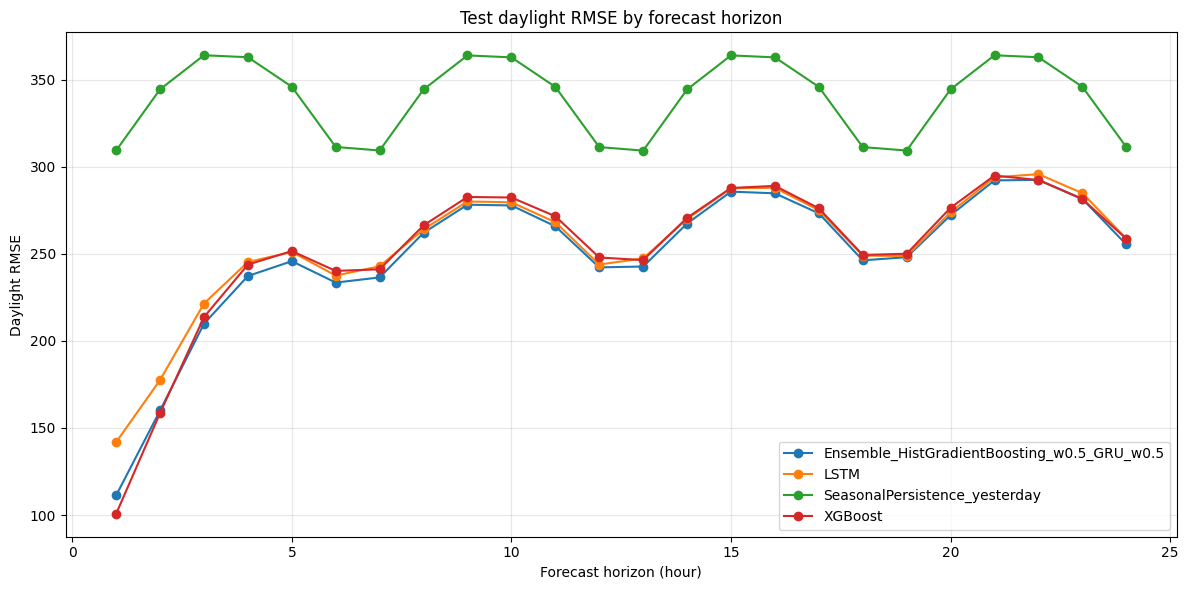

In [20]:
horizon_df = pd.DataFrame(horizon_rows)
horizon_df.to_csv(OUT_DIR / "06_horizon_metrics.csv", index=False)
print("Saved:", OUT_DIR / "06_horizon_metrics.csv")

if not horizon_df.empty and not summary_df.empty:
    selected_models = summary_df["model"].tolist()
    plot_df = horizon_df[horizon_df["model"].isin(selected_models)].copy()

    if not plot_df.empty:
        plt.figure(figsize=(12, 6))

        for model_name, g in plot_df.groupby("model"):
            g = g.sort_values("horizon")
            plt.plot(g["horizon"], g["daylight_RMSE"], marker="o", label=model_name)

        plt.xlabel("Forecast horizon (hour)")
        plt.ylabel("Daylight RMSE")
        plt.title("Test daylight RMSE by forecast horizon")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / "06_rmse_by_horizon.png", dpi=160)
        plt.show()
else:
    print("Skipping horizon plot because horizon_df or summary_df is empty.")


## 13. Daily-total-from-24h comparison

In [21]:
daily_total_rows = []

for model_name, pred_info in predictions.items():
    if "test_pred" not in pred_info:
        continue

    pred = np.clip(as_2d_horizon(pred_info["test_pred"]), 0, None)
    n = min(len(Y_test), len(pred))
    yt = Y_test[-n:]
    yp = pred[-n:]

    daily_total_rows.append({
        "model": model_name,
        "daily_total_RMSE": rmse(yt.sum(axis=1), yp.sum(axis=1)),
        "daily_total_MAE": float(mean_absolute_error(yt.sum(axis=1), yp.sum(axis=1))),
        "daily_total_R2": safe_r2(yt.sum(axis=1), yp.sum(axis=1)),
    })

daily_total_df = pd.DataFrame(daily_total_rows)

if not daily_total_df.empty:
    daily_total_df = daily_total_df.sort_values("daily_total_RMSE")
    display(daily_total_df.head(20))
else:
    print("No daily-total results available.")

daily_total_df.to_csv(OUT_DIR / "06_daily_total_from_24h_summary.csv", index=False)
print("Saved:", OUT_DIR / "06_daily_total_from_24h_summary.csv")


,model,daily_total_RMSE,daily_total_MAE,daily_total_R2
29,Ensemble_XGBoost_w0.7_TSMixer-lite_w0.3,2366.248654,1598.263315,0.848897
28,Ensemble_XGBoost_w0.5_TSMixer-lite_w0.5,2367.936401,1593.393962,0.848681
58,Ensemble_HistGradientBoosting_w0.5_TSMixer-lit...,2368.937887,1595.611337,0.848553
48,Ensemble_HistGradientBoosting_w0.5_LSTM_w0.5,2369.522675,1590.464446,0.848479
18,Ensemble_XGBoost_w0.5_LSTM_w0.5,2369.936108,1589.535628,0.848426
59,Ensemble_HistGradientBoosting_w0.7_TSMixer-lit...,2370.366212,1603.646506,0.848371
19,Ensemble_XGBoost_w0.7_LSTM_w0.3,2371.362438,1600.711816,0.848243
24,Ensemble_XGBoost_w0.7_GRU_w0.3,2371.623833,1586.156765,0.848210
30,Ensemble_XGBoost_w0.8_TSMixer-lite_w0.2,2372.173966,1607.644382,0.848139
23,Ensemble_XGBoost_w0.5_GRU_w0.5,2372.912708,1573.524377,0.848045


Saved: outputs_06\06_daily_total_from_24h_summary.csv


## 14. Error analysis theo giờ và tháng

In [22]:
if results_df.empty or not results_df["status"].eq("ok").any():
    print("No successful model found for error analysis.")
    err_long = pd.DataFrame()
    error_by_hour = pd.DataFrame()
    error_by_month = pd.DataFrame()
else:
    best_row = results_df[results_df["status"].eq("ok")].sort_values("val_daylight_RMSE").iloc[0]
    best_model_name = best_row["model"]
    best_pred = as_2d_horizon(predictions[best_model_name]["test_pred"])

    n = min(len(Y_test), len(best_pred), len(test_times))
    yt_test = Y_test[-n:]
    yp_test = best_pred[-n:]
    times_eval = pd.DatetimeIndex(test_times[-n:])

    print("Best model:", best_model_name)

    records = []

    for i, anchor in enumerate(times_eval):
        future_times = pd.date_range(anchor, periods=HORIZON, freq="h")

        for h in range(HORIZON):
            yt = float(yt_test[i, h])
            yp = float(yp_test[i, h])

            records.append({
                "anchor_time": anchor,
                "forecast_time": future_times[h],
                "horizon": h + 1,
                "hour": future_times[h].hour,
                "month": future_times[h].month,
                "y_true": yt,
                "y_pred": yp,
                "abs_error": abs(yt - yp),
                "squared_error": (yt - yp) ** 2,
                "is_daylight": yt > DAYLIGHT_THRESHOLD,
            })

    err_long = pd.DataFrame(records)

    def grouped_error(g):
        daylight = g[g["is_daylight"]]
        return pd.Series({
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "daylight_RMSE": np.sqrt(mean_squared_error(daylight["y_true"], daylight["y_pred"])) if len(daylight) > 5 else np.nan,
            "n": len(g),
        })

    error_by_hour = err_long.groupby("hour").apply(grouped_error).reset_index()
    error_by_month = err_long.groupby("month").apply(grouped_error).reset_index()

    error_analysis = pd.concat([
        error_by_hour.assign(analysis_type="by_hour"),
        error_by_month.assign(analysis_type="by_month"),
    ], ignore_index=True)

    error_analysis.to_csv(OUT_DIR / "06_error_analysis.csv", index=False)

    display(error_by_hour.head())
    display(error_by_month.head())


Best model: Ensemble_HistGradientBoosting_w0.5_GRU_w0.5


,hour,MAE,RMSE,daylight_RMSE,n
0,0,4.273193,6.061153,NaN,4377.0
1,1,5.636972,8.533331,NaN,4377.0
2,2,5.014609,7.893970,NaN,4377.0
3,3,7.274181,11.831651,NaN,4377.0
4,4,8.082350,13.143953,NaN,4377.0


,month,MAE,RMSE,daylight_RMSE,n
0,1,56.392943,135.932748,200.632274,8892.0
1,2,93.010328,221.359283,326.823523,8064.0
2,3,89.961826,190.441278,263.735638,8928.0
3,4,87.934184,163.400011,220.698867,8640.0
4,5,112.265235,223.301031,292.203155,8928.0


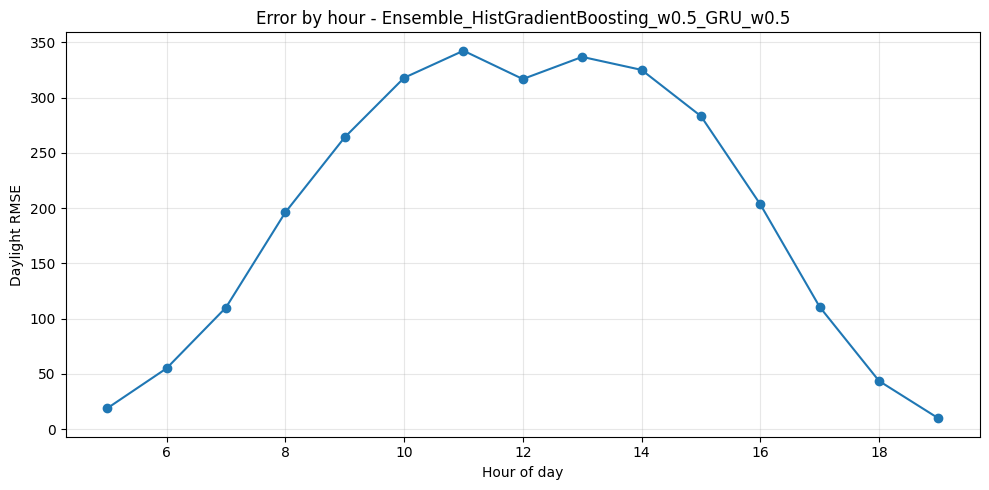

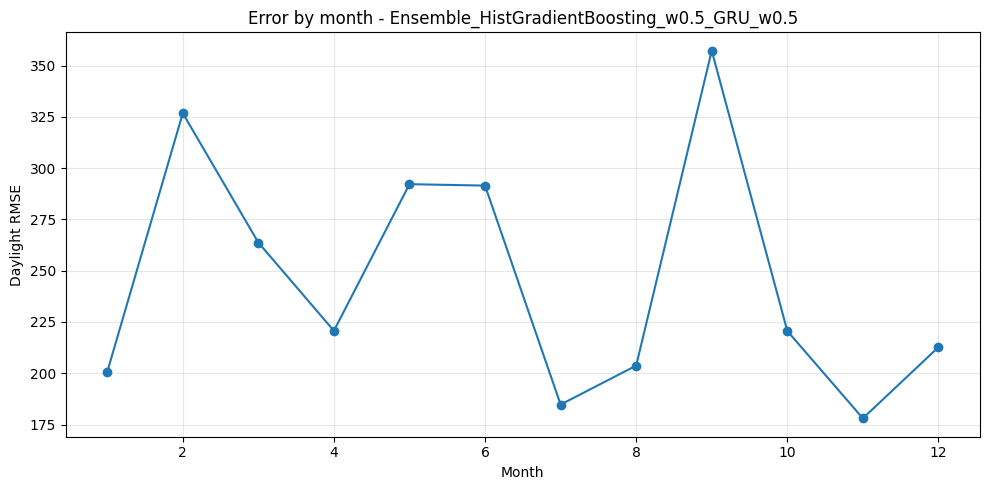

In [23]:
if "error_by_hour" in globals() and not error_by_hour.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(error_by_hour["hour"], error_by_hour["daylight_RMSE"], marker="o")
    plt.xlabel("Hour of day")
    plt.ylabel("Daylight RMSE")
    plt.title(f"Error by hour - {best_model_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "06_error_by_hour.png", dpi=160)
    plt.show()

if "error_by_month" in globals() and not error_by_month.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(error_by_month["month"], error_by_month["daylight_RMSE"], marker="o")
    plt.xlabel("Month")
    plt.ylabel("Daylight RMSE")
    plt.title(f"Error by month - {best_model_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "06_error_by_month.png", dpi=160)
    plt.show()


## 15. Permutation importance cho best tabular model

Best tabular model: XGBoost


,model,feature,base_daily_total_RMSE,permuted_daily_total_RMSE,importance_delta_RMSE
6,XGBoost,Solar_Energy_kJ_m2_lag_1h,2308.698443,3380.839541,1072.141098
36,XGBoost,future_h5_clear_sky_proxy,2308.698443,2560.084960,251.386517
35,XGBoost,future_h8_clear_sky_proxy,2308.698443,2387.118451,78.420008
38,XGBoost,future_h11_clear_sky_proxy,2308.698443,2380.370034,71.671591
34,XGBoost,future_h2_clear_sky_proxy,2308.698443,2374.632498,65.934055
9,XGBoost,Solar_Energy_kJ_m2_mean_3h,2308.698443,2369.163460,60.465017
5,XGBoost,Solar_Energy_kJ_m2_lag_12h,2308.698443,2361.734955,53.036513
27,XGBoost,future_h6_clear_sky_proxy,2308.698443,2355.542082,46.843639
0,XGBoost,Solar_Energy_kJ_m2_max_6h,2308.698443,2350.036170,41.337727
8,XGBoost,Solar_Energy_kJ_m2_lag_2h,2308.698443,2335.158346,26.459903


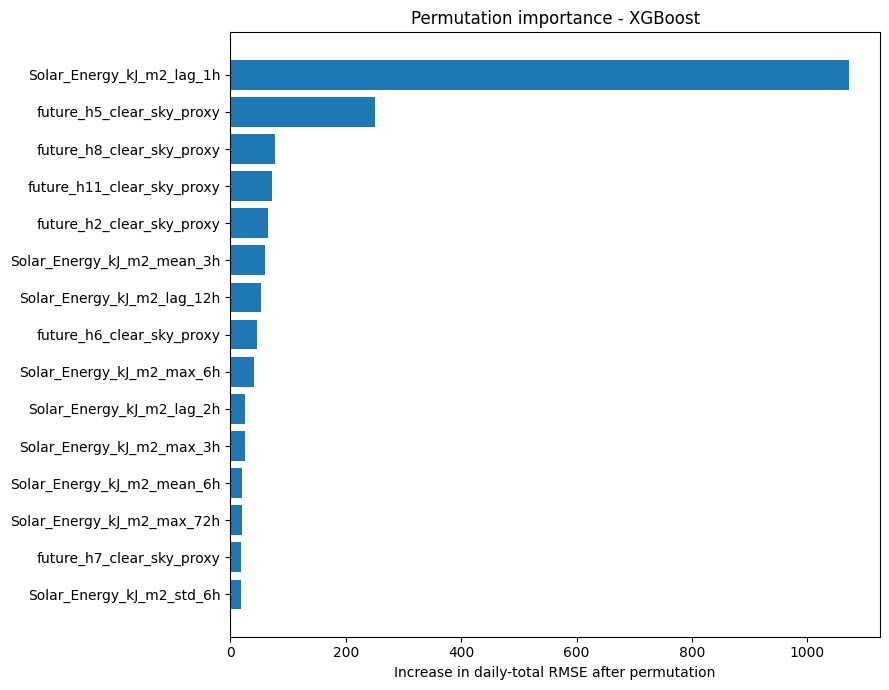

In [24]:
feature_importance_df = pd.DataFrame()

if RUN_PERMUTATION_IMPORTANCE:
    if results_df.empty:
        print("No results available for permutation importance.")
    else:
        tabular_ok = results_df[
            (results_df["model_group"].eq("tabular_ml"))
            & (results_df["status"].eq("ok"))
        ].copy()

        if not tabular_ok.empty:
            best_tabular_name = tabular_ok.sort_values("val_daylight_RMSE").iloc[0]["model"]
            print("Best tabular model:", best_tabular_name)

            best_tabular_model = predictions[best_tabular_name]["model"]

            rng = np.random.default_rng(SEED)
            n_sample = min(800, len(X_test_tab))
            sample_idx = rng.choice(len(X_test_tab), size=n_sample, replace=False)

            X_sample = X_test_tab.iloc[sample_idx].copy()
            Y_sample = Y_test[sample_idx].copy()

            base_pred = ensure_2d_prediction(
                best_tabular_model.predict(X_sample),
                n_samples=len(X_sample),
                horizon=HORIZON,
            )

            base_score = rmse(Y_sample.sum(axis=1), base_pred.sum(axis=1))

            rows = []
            candidate_cols = X_sample.var().sort_values(ascending=False).head(40).index.tolist()

            for col in candidate_cols:
                X_perm = X_sample.copy()
                X_perm[col] = rng.permutation(X_perm[col].values)

                perm_pred = ensure_2d_prediction(
                    best_tabular_model.predict(X_perm),
                    n_samples=len(X_perm),
                    horizon=HORIZON,
                )

                perm_score = rmse(Y_sample.sum(axis=1), perm_pred.sum(axis=1))

                rows.append({
                    "model": best_tabular_name,
                    "feature": col,
                    "base_daily_total_RMSE": base_score,
                    "permuted_daily_total_RMSE": perm_score,
                    "importance_delta_RMSE": perm_score - base_score,
                })

            feature_importance_df = pd.DataFrame(rows).sort_values("importance_delta_RMSE", ascending=False)

            display(feature_importance_df.head(20))

            feature_importance_df.to_csv(OUT_DIR / "06_feature_importance.csv", index=False)

            plt.figure(figsize=(9, 7))
            top_imp = feature_importance_df.head(15).iloc[::-1]
            plt.barh(top_imp["feature"], top_imp["importance_delta_RMSE"])
            plt.xlabel("Increase in daily-total RMSE after permutation")
            plt.title(f"Permutation importance - {best_tabular_name}")
            plt.tight_layout()
            plt.savefig(FIG_DIR / "06_feature_importance.png", dpi=160)
            plt.show()

        else:
            print("No successful tabular model for permutation importance.")


## 16. Lưu training history và kết luận nhanh

In [25]:
history_df = pd.concat(training_history_rows, ignore_index=True) if training_history_rows else pd.DataFrame()
history_df.to_csv(OUT_DIR / '06_training_history.csv', index=False)
print('Saved:', OUT_DIR / '06_training_history.csv')
print('Notebook 06 completed.')
print('Outputs:', OUT_DIR.resolve())
print('Figures:', FIG_DIR.resolve())
print('Models :', MODEL_DIR.resolve())

Saved: outputs_06\06_training_history.csv
Notebook 06 completed.
Outputs: C:\Users\nguye\Downloads\Big_Data\outputs_06
Figures: C:\Users\nguye\Downloads\Big_Data\figures_06
Models : C:\Users\nguye\Downloads\Big_Data\models_06


## Lưu ý

Notebook 06 không nhằm ép mô hình phức tạp luôn thắng, mà kiểm tra chúng trong bài toán **multi-horizon 24h forecasting** phù hợp hơn.

Các điểm cần quan sát:

1. Mô hình nào tốt nhất ở overall 24h daylight RMSE?
2. Mô hình nào tốt nhất ở horizon 1?
3. Mô hình nào tốt nhất ở horizon 24?
4. Mô hình nào tốt nhất khi lấy tổng 24 giờ?
5. Ensemble giữa tabular/boosting và deep sequence có cải thiện không?
6. RMSE theo horizon có cho thấy deep models cạnh tranh hơn ở horizon dài không?